# News recommendation with text embeddings

News recommendation is an extreme cold-start problem: articles are relevant for a day or two, so most of the articles to rank were published after the model was trained, and nobody has clicked on them yet. Collaborative filtering cannot score them; the content of the article has to do the work.

We use **MIND** (Microsoft News Dataset, small version): impressions logged on MSN News in November 2019. Each impression is a list of articles shown to a user, with the user's click history and which articles they clicked. The task is to **rank the articles of each impression** so that the clicked ones come first.

We compare:

1. trivial baselines (random, popularity on the previous days, preferred categories);
2. a content-based recommender on **TF-IDF** vectors of the articles;
3. the same recommender on **sentence embeddings** from a pre-trained Transformer (`all-MiniLM-L6-v2`).

The data are not redistributed here: download *MINDsmall_train* and *MINDsmall_dev* from the [MIND website](https://msnews.github.io/) into `data/MIND/`.

In [1]:
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import normalize

plt.rcParams["figure.dpi"] = 100

news_cols = ["news_id", "category", "subcategory", "title", "abstract", "url", "title_entities", "abstract_entities"]
behavior_cols = ["impression_id", "user_id", "time", "history", "impressions"]
read = lambda split, name, cols: pd.read_csv(f"data/MIND/MINDsmall_{split}/{name}.tsv", sep="\t", header=None, names=cols)

news = pd.concat([read("train", "news", news_cols), read("dev", "news", news_cols)]).drop_duplicates("news_id").reset_index(drop=True)
news["text"] = news["title"].fillna("") + ". " + news["abstract"].fillna("")
train_beh, dev_beh = read("train", "behaviors", behavior_cols), read("dev", "behaviors", behavior_cols)
for b in (train_beh, dev_beh):
    b["time"] = pd.to_datetime(b["time"])
    b["history"] = b["history"].fillna("").str.split()
    b["candidates"] = b["impressions"].str.split().apply(lambda l: [x[:-2] for x in l])
    b["labels"] = b["impressions"].str.split().apply(lambda l: np.array([int(x[-1]) for x in l]))

print(f"{len(news):,} articles; train impressions: {len(train_beh):,} ({train_beh['time'].min():%d %b} - {train_beh['time'].max():%d %b}); "
      f"evaluation impressions: {len(dev_beh):,} ({dev_beh['time'].min():%d %b})")

65,238 articles; train impressions: 156,965 (09 Nov - 14 Nov); evaluation impressions: 73,152 (15 Nov)


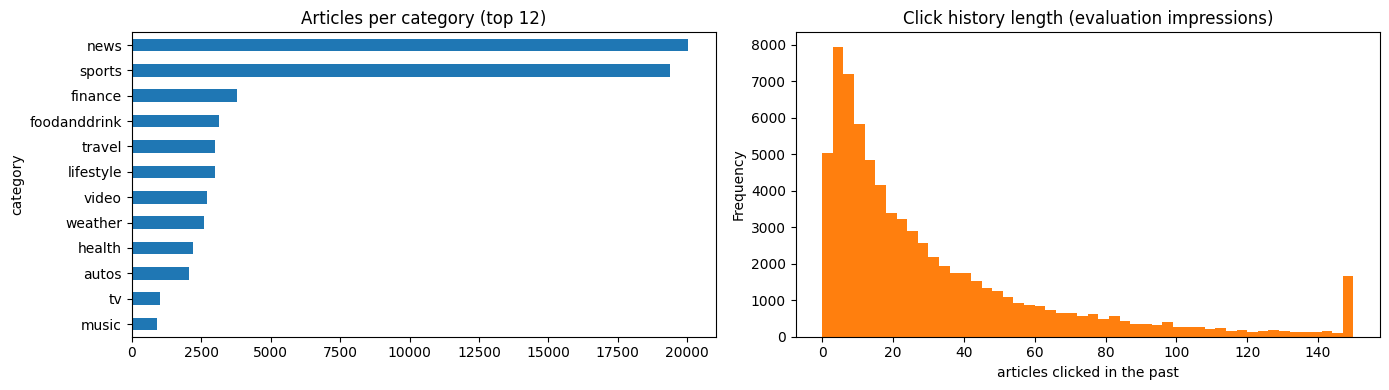

candidates per impression (mean)                    37.470
clicks per impression (mean)                         1.523
click-through rate                                   0.041
candidate articles not seen in the training days     0.200
evaluation users never seen in training              0.878
evaluation impressions with an empty history         0.030
dtype: float64

In [2]:
train_ids = set(read("train", "news", news_cols)["news_id"])
cand_lengths = dev_beh["candidates"].str.len()
clicks = dev_beh["labels"].apply(np.sum)
new_share = np.mean([c not in train_ids for cands in dev_beh["candidates"] for c in cands])
stats = pd.Series({
    "candidates per impression (mean)": cand_lengths.mean(),
    "clicks per impression (mean)": clicks.mean(),
    "click-through rate": clicks.sum() / cand_lengths.sum(),
    "candidate articles not seen in the training days": new_share,
    "evaluation users never seen in training": 1 - dev_beh["user_id"].isin(train_beh["user_id"]).mean(),
    "evaluation impressions with an empty history": (dev_beh["history"].str.len() == 0).mean(),
})
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
news["category"].value_counts().head(12).plot.barh(ax=axes[0], color="tab:blue")
axes[0].invert_yaxis()
axes[0].set_title("Articles per category (top 12)")
dev_beh["history"].str.len().clip(upper=150).plot.hist(bins=50, ax=axes[1], color="tab:orange")
axes[1].set(title="Click history length (evaluation impressions)", xlabel="articles clicked in the past")
fig.tight_layout()
plt.show()
stats.round(3)

The setting is exactly the cold-start scenario described above:

- the evaluation day is the day **after** the training period, and **45%** of the articles to rank were never shown during training;
- **88%** of the evaluation users never appear in the training impressions, but nearly all of them come with a click history;
- each impression shows about 37 articles, of which on average 1.5 are clicked (click-through rate of about 4%).

Collaborative filtering would have nothing to work with. The click history and the text of the articles are the available signals.

## 1. Evaluation

For each impression we score its candidates and compute the standard MIND metrics, then average over impressions:

- **AUC**: probability that a clicked article is ranked above a non-clicked one (0.5 = random);
- **MRR**: mean reciprocal rank of the clicked articles;
- **nDCG@5** and **nDCG@10**: quality of the top of the ranking, rewarding clicks in the first positions.

In [3]:
from sklearn.metrics import roc_auc_score

def ranking_metrics(scores, labels):
    order = np.argsort(-scores)
    ranked = labels[order]
    gains = ranked / np.log2(np.arange(2, len(ranked) + 2))
    ideal = np.sort(labels)[::-1] / np.log2(np.arange(2, len(labels) + 2))
    ndcg = lambda k: gains[:k].sum() / ideal[:k].sum()
    mrr = (ranked / np.arange(1, len(ranked) + 1)).sum() / ranked.sum()
    return roc_auc_score(labels, scores), mrr, ndcg(5), ndcg(10)

def evaluate(score_fn, behaviors=dev_beh, seed=0):
    rng = np.random.default_rng(seed)
    rows = []
    for history, cands, labels in zip(behaviors["history"], behaviors["candidates"], behaviors["labels"]):
        if labels.sum() in (0, len(labels)):
            continue
        scores = score_fn(history, cands) + 1e-9 * rng.random(len(cands))   # random tie-breaking
        rows.append(ranking_metrics(scores, labels))
    return pd.Series(np.mean(rows, axis=0), index=["AUC", "MRR", "nDCG@5", "nDCG@10"])

results = {"random": evaluate(lambda h, c: np.zeros(len(c)))}
results["random"].round(4)

AUC        0.5008
MRR        0.2189
nDCG@5     0.2239
nDCG@10    0.2868
dtype: float64

## 2. Baselines

- **Popularity**: the number of clicks each article received in the training days. Brand-new articles get zero.
- **Preferred categories**: score each candidate by the share of the user's history that belongs to its category (sport, news, lifestyle, ...).

In [4]:
train_clicks = pd.Series([c for cands, labels in zip(train_beh["candidates"], train_beh["labels"])
                          for c, l in zip(cands, labels) if l]).value_counts()
category = news.set_index("news_id")["category"]

def popularity(history, cands):
    return train_clicks.reindex(cands).fillna(0).to_numpy()

def category_preference(history, cands):
    if not history:
        return np.zeros(len(cands))
    share = category.reindex(history).value_counts(normalize=True)
    return share.reindex(category.reindex(cands)).fillna(0).to_numpy()

start = time.time()
results["popularity (training days)"] = evaluate(popularity)
results["preferred categories"] = evaluate(category_preference)
print(f"evaluated in {time.time() - start:.0f} s")
pd.DataFrame(results).T.round(4)

evaluated in 128 s


,AUC,MRR,nDCG@5,nDCG@10
random,0.5008,0.2189,0.2239,0.2868
popularity (training days),0.5314,0.2374,0.2454,0.3091
preferred categories,0.5979,0.2726,0.2923,0.3545


## 3. Content-based recommendation

A user profile is the **average vector of the articles in their click history**, and each candidate is scored by its cosine similarity with the profile. Two representations of an article:

- **TF-IDF** on title and abstract: a sparse bag of words, weighted by how distinctive each word is. Two articles are similar only if they share words.
- **Sentence embeddings**: `all-MiniLM-L6-v2`, a small Transformer pre-trained to map sentences with similar meaning to nearby 384-dimensional vectors, even when they share no words ("Lakers beat Celtics" and "NBA game result").

In [5]:
news_pos = {nid: k for k, nid in enumerate(news["news_id"])}

def content_recommender(vectors):
    def score(history, cands):
        hist = [news_pos[h] for h in history if h in news_pos]
        if not hist:
            return np.zeros(len(cands))
        profile = np.asarray(vectors[hist].mean(axis=0)).ravel()
        cand_vecs = vectors[[news_pos[c] for c in cands]]
        return np.asarray(cand_vecs @ profile).ravel()
    return score

tfidf = TfidfVectorizer(stop_words="english", max_features=50_000, min_df=2, sublinear_tf=True)
tfidf_vectors = normalize(tfidf.fit_transform(news["text"]))
start = time.time()
results["content: TF-IDF"] = evaluate(content_recommender(tfidf_vectors))
print(f"TF-IDF: {tfidf_vectors.shape[1]:,} terms, evaluated in {time.time() - start:.0f} s")

TF-IDF: 36,509 terms, evaluated in 58 s


In [6]:
from sentence_transformers import SentenceTransformer

encoder = SentenceTransformer("all-MiniLM-L6-v2", device="cpu")
start = time.time()
embeddings = encoder.encode(news["text"].tolist(), batch_size=256, normalize_embeddings=True, show_progress_bar=False)
print(f"{len(embeddings):,} articles embedded in {(time.time() - start) / 60:.1f} min, dimension {embeddings.shape[1]}")
results["content: sentence embeddings"] = evaluate(content_recommender(embeddings))
summary = pd.DataFrame(results).T
summary.round(4)

65,238 articles embedded in 12.6 min, dimension 384


,AUC,MRR,nDCG@5,nDCG@10
random,0.5008,0.2189,0.2239,0.2868
popularity (training days),0.5314,0.2374,0.2454,0.3091
preferred categories,0.5979,0.2726,0.2923,0.3545
content: TF-IDF,0.5785,0.2780,0.2968,0.3581
content: sentence embeddings,0.6356,0.3085,0.3373,0.3960


- **Popularity** from the previous days barely beats random (AUC 0.53): half the candidates are brand new, and yesterday's hits are not today's.
- Simply favouring the user's **preferred categories** is a strong baseline (AUC 0.60).
- **TF-IDF** profiles have a better ranking at the top (MRR, nDCG) than categories but a lower AUC. Exact word overlap is a brittle similarity: two articles about the same game can share almost no words.
- **Sentence embeddings** are the best on every metric (AUC 0.64, nDCG@10 0.40), with no training on news data at all: the pre-trained encoder already knows that different words can express the same topic.

For reference, models trained end to end on MIND reach AUCs around 0.66–0.68 on this data. A pre-trained encoder with an averaged profile gets most of the way there.

### Combining content and popularity

Content tells *what* a user likes; popularity tells what *everybody* is reading right now. A simple combination adds a popularity term to the embedding score. Since popularity counts span several orders of magnitude, we use their logarithm and choose the weight on a separate sample of impressions from the last training day, not on the evaluation day.

In [7]:
embed_score = content_recommender(embeddings)
log_pop = lambda c: np.log1p(popularity(None, c))
tuning = train_beh[train_beh["time"] >= train_beh["time"].max().normalize()].sample(5000, random_state=0)
tuning_scores = {w: evaluate(lambda h, c, w=w: embed_score(h, c) + w * log_pop(c), behaviors=tuning)["AUC"] for w in (0, 0.01, 0.02, 0.05, 0.1)}
best_w = max(tuning_scores, key=tuning_scores.get)
print("AUC on the tuning impressions:", {w: round(a, 4) for w, a in tuning_scores.items()}, "-> weight", best_w)

results[f"embeddings + popularity (w = {best_w})"] = evaluate(lambda h, c: embed_score(h, c) + best_w * log_pop(c))
summary = pd.DataFrame(results).T
summary.round(4)

AUC on the tuning impressions: {0: 0.6337, 0.01: 0.6476, 0.02: 0.6479, 0.05: 0.6348, 0.1: 0.6135} -> weight 0.02


,AUC,MRR,nDCG@5,nDCG@10
random,0.5008,0.2189,0.2239,0.2868
popularity (training days),0.5314,0.2374,0.2454,0.3091
preferred categories,0.5979,0.2726,0.2923,0.3545
content: TF-IDF,0.5785,0.2780,0.2968,0.3581
content: sentence embeddings,0.6356,0.3085,0.3373,0.3960
embeddings + popularity (w = 0.02),0.6245,0.2894,0.3102,0.3718


On the tuning impressions from the last training day, a small popularity weight improved the AUC from 0.634 to 0.648. On the evaluation day, however, the same combination makes the embedding model **worse** (AUC 0.625 vs 0.636). Popularity measured on the training days transfers poorly to the next day's articles, which are largely new and have zero training clicks. The tuning day did not reflect that, because many of its candidates had already been clicked in earlier impressions on the same day. A useful popularity signal for news must be **fresh**, computed within hours rather than days.

### Who benefits?

The value of a content profile should depend on how much history a user has:

In [8]:
def per_impression_auc(score_fn, behaviors):
    out = []
    for history, cands, labels in zip(behaviors["history"], behaviors["candidates"], behaviors["labels"]):
        if labels.sum() in (0, len(labels)):
            out.append(np.nan)
        else:
            out.append(roc_auc_score(labels, score_fn(history, cands) + 1e-9 * np.random.default_rng(0).random(len(cands))))
    return np.array(out)

sample = dev_beh.sample(20_000, random_state=1)
groups = pd.cut(sample["history"].str.len(), [-1, 0, 5, 20, 50, 1000], labels=["0", "1-5", "6-20", "21-50", "> 50"])
by_history = pd.DataFrame({
    "impressions": groups.value_counts().sort_index(),
    "popularity": pd.Series(per_impression_auc(popularity, sample), index=sample.index).groupby(groups, observed=True).mean(),
    "TF-IDF": pd.Series(per_impression_auc(content_recommender(tfidf_vectors), sample), index=sample.index).groupby(groups, observed=True).mean(),
    "embeddings": pd.Series(per_impression_auc(embed_score, sample), index=sample.index).groupby(groups, observed=True).mean(),
})
by_history.index.name = "clicked articles in history"
by_history.round(3)

,impressions,popularity,TF-IDF,embeddings
clicked articles in history,,,,
0,616,0.523,0.489,0.489
1-5,2903,0.542,0.530,0.604
6-20,6928,0.544,0.566,0.638
21-50,5677,0.525,0.601,0.658
> 50,3876,0.515,0.610,0.652


- With an **empty history** the content models have no profile and fall back to random ordering (AUC about 0.49); only popularity gives a small signal there.
- With **1–5 clicks**, embeddings already work (AUC 0.60) while TF-IDF does not: a handful of articles rarely shares exact words with tomorrow's news, but it does share topics.
- The content profiles improve as the history grows and level off beyond about 20 clicks. Embeddings stay ahead of TF-IDF in every group, and the gap is largest for users with little history.

### An example

In [9]:
example = dev_beh[(dev_beh["history"].str.len().between(8, 15)) & (dev_beh["labels"].apply(sum) == 1) & (dev_beh["candidates"].str.len() >= 10)].iloc[3]
titles = news.set_index("news_id")["title"]
print("Recently clicked:")
for h in example["history"][-6:]:
    print(f"  [{category[h]}] {titles[h]}")
scores = embed_score(example["history"], example["candidates"])
ranked = pd.DataFrame({"title": titles.reindex(example["candidates"]).to_numpy(), "category": category.reindex(example["candidates"]).to_numpy(),
                       "score": scores, "clicked": example["labels"]}).sort_values("score", ascending=False)
ranked.head(10).round(3)

Recently clicked:
  [finance] Eric Tse, 24, just became a billionaire overnight
  [news] Coast Guard searches for man who fell from cruise off Texas
  [video] Where have Cape Town's great whites gone?
  [movies] Kevin Spacey Won't Be Charged in Sexual Assault Case After Accuser Dies
  [foodanddrink] Chick-fil-A Apologizes to Customers for Promoting National Sandwich Day   Which Is on a Sunday
  [news] A man dies in Hawaii after falling into a lava tube in his yard


,title,category,score,clicked
2,Report: Police investigating woman's death aft...,sports,0.139,0
10,South Carolina teen gets life in prison for de...,news,0.110,0
9,The Real Reason McDonald's Keeps the Filet-O-F...,foodanddrink,0.097,0
4,Cows swept away by Hurricane Dorian found aliv...,lifestyle,0.090,0
3,"Taylor Swift Rep Hits Back at Big Machine, Cla...",music,0.087,0
5,13 Reasons Why's Christian Navarro Slams Disne...,movies,0.087,0
1,"Pete Davidson, Kaia Gerber Are Dating, Trying ...",tv,0.077,0
7,Opinion: Colin Kaepernick is about to get what...,sports,0.060,1
0,"U.S. Troops Will Die If They Remain in Syria, ...",news,0.054,0
6,"Some believe Mason Rudolph, hit in head with h...",sports,0.054,0


The example shows both the strength and the limit of the approach. This user's history is a mix of human-interest stories, accidents and celebrity news, and the model ranks similar articles at the top (a police investigation, a court case, a food-chain story). The one article actually clicked, an opinion piece about an American football player, ends up eighth: nothing in the history announced an interest in sport. News clicks are driven by curiosity and by the moment as much as by stable interests, which is why even the best models on MIND stay far from perfect.

## Summary

- In news recommendation most candidates are **new**: about half the articles to rank were never seen during training, and most users were never seen either. Methods that rely on past interactions with an item cannot score them.
- A **content profile** built from the user's click history needs neither: it works for new articles and for new users, as long as they have clicked something.
- **Sentence embeddings** capture meaning beyond shared words and outperform TF-IDF, with no training on the news data at all.
- **Popularity** decays fast in news: clicks from previous days barely beat random and even hurt when added to the content model. It is only useful if computed on fresh data.